# Chapter 10 - Gaussian Mixture Model - Exercises

### Nguyễn Phúc Minh Châu - 22302421

## Q1. Plot the probability density function of a Gaussian with a mean of 0 and a standard deviation of 1.5.

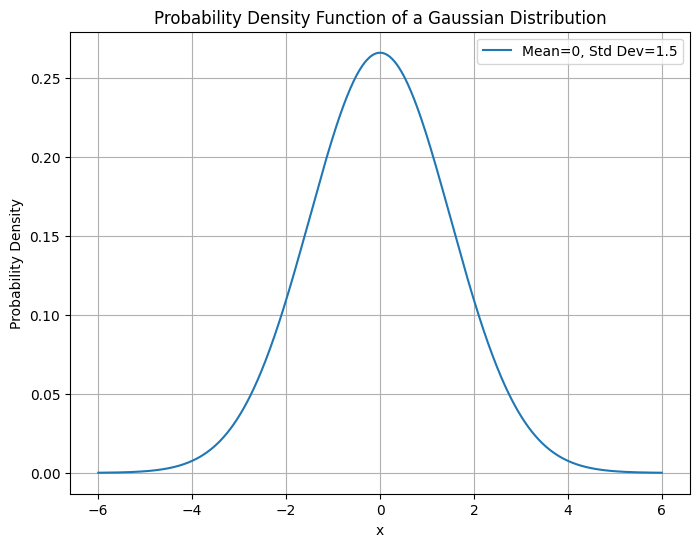

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Define the parameters of the Gaussian distribution
mu = 0       # Mean
sigma = 1.5  # Standard deviation
variance = sigma**2 # Calculate variance

# Generate a range of x-values
x = np.linspace(mu - 4 * sigma, mu + 4 * sigma, 500)

# Calculate the probability density function (PDF) using the explicit formula
pdf = (1 / np.sqrt(2 * np.pi * variance)) * np.exp(- (x - mu)**2 / (2 * variance))

# Plot the PDF
plt.figure(figsize=(8, 6))
plt.plot(x, pdf, label=f'Mean={mu}, Std Dev={sigma}')
plt.title('Probability Density Function of a Gaussian Distribution')
plt.xlabel('x')
plt.ylabel('Probability Density')
plt.grid(True)
plt.legend()
plt.show()

## Q2. Gaussian Mixture Model

In [ ]:
# Generating Synthetic Data
import numpy as np

# Parameters
mu = [-1, 0, 2]
sigma_sq = [2.5, 1.6, 1.25]
weights = [0.2, 0.5, 0.3]

N_samples = 1000
N1 = int(N_samples * weights[0]) # ? samples
N2 = int(N_samples * weights[1]) # ? samples
N3 = int(N_samples * weights[2]) # ? samples

# Generate samples from each 1D Gaussian
comp_1 = np.random.normal(mu[0], np.sqrt(sigma_sq[0]), N1)
comp_2 = np.random.normal(mu[1], np.sqrt(sigma_sq[1]), N2)
comp_3 = np.random.normal(mu[2], np.sqrt(sigma_sq[2]), N3)

# Combine into the input dataset X
X = np.concatenate([comp_1, comp_2, comp_3])

In [ ]:
# Fitting the Mixed Distribution Model
from sklearn.mixture import GaussianMixture
# X must be reshaped for scikit-learn compatibility (N samples, 1 feature)
X = X.reshape(-1, 1)

# Fit GMM model with 3 components (K=3)
# The EM algorithm works internally here to find optimal mu, sigma, and weights.
gmm = GaussianMixture(n_components=3, random_state=42)
gmm.fit(X)

# The model 'gmm' now contains the learned mean, covariance, and weights

GaussianMixture(n_components=3, random_state=42)

In [ ]:
# cluster labeling
labels = gmm.predict(X)
print(labels)

[0 0 0 2 0 2 0 0 0 2 1 2 2 1 2 2 2 2 0 1 2 2 2 2 0 0 0 0 1 0 2 0 0 0 0 0 1
 0 0 2 1 2 2 0 0 2 2 0 2 2 2 2 1 2 1 0 0 1 2 2 0 0 2 0 0 0 0 0 1 2 2 0 0 0
 2 0 2 2 0 0 0 2 2 2 2 0 0 0 1 2 2 2 0 0 0 0 0 2 0 0 1 0 0 0 0 1 1 0 2 0 2
 1 2 2 0 2 2 2 2 2 2 2 0 0 1 1 0 2 1 2 0 0 2 0 0 2 0 2 0 0 2 2 2 2 2 2 0 0
 0 0 2 2 2 0 0 2 0 2 1 2 1 1 2 2 2 0 2 0 0 0 2 0 0 2 0 0 1 0 2 1 0 0 0 0 0
 0 0 0 0 2 2 1 2 0 0 2 2 2 1 0 0 0 0 0 0 1 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 1
 1 0 2 0 0 0 0 0 0 1 1 0 0 0 1 0 0 0 0 1 0 0 1 0 1 0 0 1 0 1 1 1 0 0 0 1 0
 0 0 0 2 0 1 2 0 0 0 1 1 1 1 0 2 0 0 1 1 0 0 0 0 1 0 0 0 0 2 0 1 1 0 0 0 0
 0 0 2 0 2 1 0 1 0 0 2 2 1 0 0 0 2 1 2 0 0 2 0 0 1 0 0 2 1 0 0 1 2 1 0 0 0
 1 1 0 0 1 2 0 2 2 0 0 0 0 0 0 0 2 1 0 0 0 0 0 0 2 0 2 1 2 1 0 0 0 0 0 1 2
 0 0 0 0 0 2 0 1 1 0 0 2 0 0 1 0 1 1 1 0 1 0 1 0 0 2 1 0 1 0 0 1 1 2 0 0 0
 0 1 1 0 1 0 1 1 0 1 2 2 0 1 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 2 2 0 0 0 1
 2 0 0 0 0 1 0 0 0 0 0 2 0 1 0 0 0 2 0 0 0 0 0 1 1 2 1 2 1 0 1 1 0 1 2 1 1
 0 0 1 0 0 0 1 0 2 2 0 1 

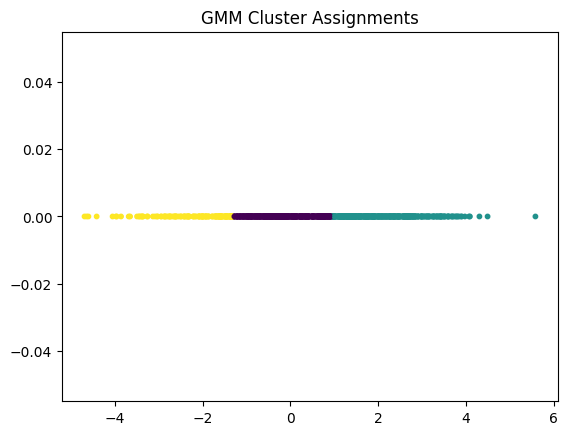

In [ ]:
# Plot Clusters
import matplotlib.pyplot as plt
plt.scatter(X, np.zeros_like(X), c=labels, s=10)
plt.title("GMM Cluster Assignments")
plt.show()

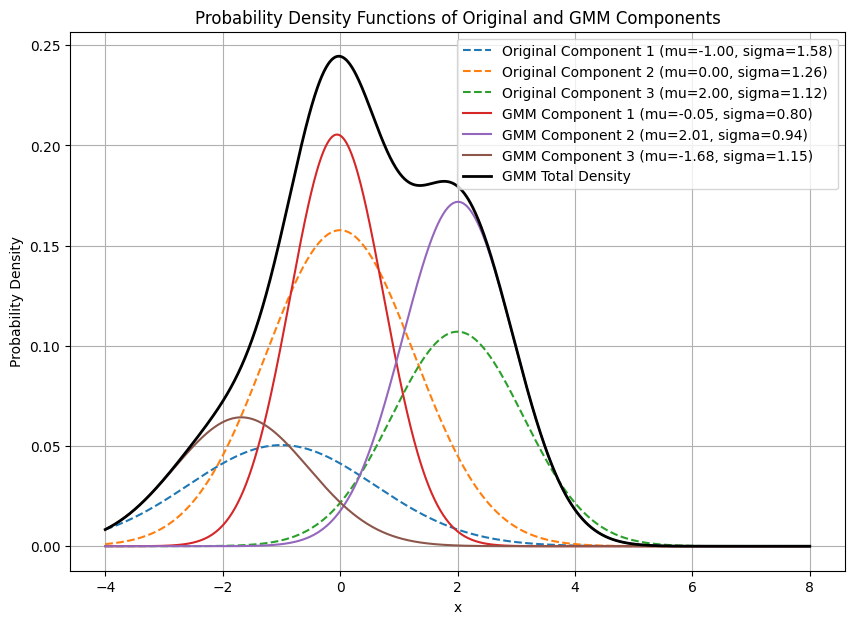

In [ ]:
# Plot the PDF of the Gaussian components on a figure
import matplotlib.pyplot as plt
import numpy as np

# Define the range for plotting
xs = np.linspace(-4, 8, 1000).reshape(-1, 1)

plt.figure(figsize=(10, 7))

# Plot the PDFs of the original synthetic components
original_mu = [-1, 0, 2]
original_sigma = [np.sqrt(2.5), np.sqrt(1.6), np.sqrt(1.25)]
original_weights = [0.2, 0.5, 0.3]

for i in range(len(original_mu)):
    mu_orig = original_mu[i]
    sigma_orig = original_sigma[i]
    variance_orig = sigma_orig**2
    weight_orig = original_weights[i]

    # Calculate PDF for each original component using the explicit formula
    pdf_comp_orig = weight_orig * (1 / np.sqrt(2 * np.pi * variance_orig)) * np.exp(- (xs.flatten() - mu_orig)**2 / (2 * variance_orig))
    plt.plot(xs, pdf_comp_orig, linestyle='--', label=f'Original Component {i+1} (mu={mu_orig:.2f}, sigma={sigma_orig:.2f})')


# Plot the PDFs of the GMM-estimated components
for i in range(gmm.n_components):
    mean = gmm.means_[i][0]
    variance = gmm.covariances_[i][0][0]
    std_dev = np.sqrt(variance)
    weight = gmm.weights_[i]

    # Calculate PDF for each component, scaled by its weight, using the explicit formula
    pdf_component = weight * (1 / np.sqrt(2 * np.pi * variance)) * np.exp(- (xs.flatten() - mean)**2 / (2 * variance))
    plt.plot(xs, pdf_component, label=f'GMM Component {i+1} (mu={mean:.2f}, sigma={std_dev:.2f})')

# Plot the overall GMM estimated density (already calculated in 'density')
plt.plot(xs, density, color='black', linewidth=2, label='GMM Total Density')

plt.title('Probability Density Functions of Original and GMM Components')
plt.xlabel('x')
plt.ylabel('Probability Density')
plt.legend()
plt.grid(True)
plt.show()

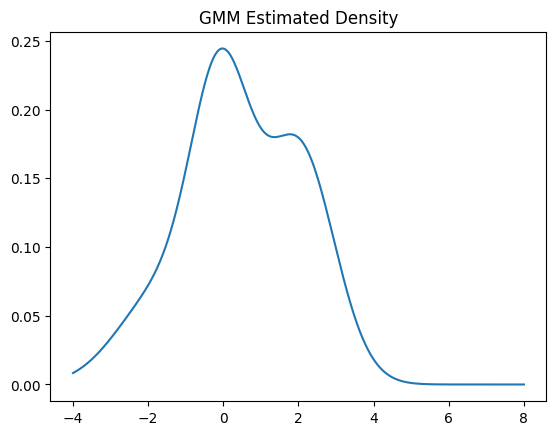

In [ ]:
# Plot the PDF of GMM
# Tạo dãy giá trị x từ -4 đến 8 gồm 1000 điểm
# reshape(-1, 1): chuyển thành vector cột để đưa vào GMM
xs = np.linspace(-4, 8, 1000).reshape(-1, 1)

# Tính mật độ (density) mà GMM ước lượng tại mỗi điểm x
density = np.exp(gmm.score_samples(xs))
# Vẽ đồ thị mật độ PDF của GMM
plt.plot(xs, density)
plt.title("GMM Estimated Density")
plt.show()